# [LAB 10] 3. 다중로지스틱회귀
## 01. 준비작업
### 1. 패키지 참조

In [1]:
from hossam import load_data
from helpers import *

import numpy as np
from IPython.display import display, Markdown

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: develop


### 2. 데이터 가져오기

In [2]:
origin = load_data('pima_indians_diabetes')
origin.head()

📚 이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


## #02. 데이터 품질 검사
### 1. 자료형 점검

In [3]:
df1 = my_qtcheck.set_type(origin, as_category=['Outcome'])
df1.head()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 48.9 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


### 2. 중복 검사 및 중복 데이터 삭제

In [4]:
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


### 3. 결측치 확인

In [5]:
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
Pregnancies,0,0.000
Glucose,0,0.000
BloodPressure,0,0.000
SkinThickness,0,0.000
Insulin,0,0.000
BMI,0,0.000
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


### 4. 연속형 변수의 기술통계량 확인

In [6]:
desc = my_qtcheck.numerical_summary(df2)
desc

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000,0.282,diff,5.000,13.500,-6.500,4,0.005,0,0.000,4,0.005,0.902,right tail,0.159,leptokurtic,log1p
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000,0.033,similar,41.250,202.125,37.125,0,0.000,5,0.007,5,0.007,0.174,symmetric,0.641,leptokurtic,none
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000,0.040,similar,18.000,107.000,35.000,7,0.009,38,0.049,45,0.059,-1.844,left tail,5.180,leptokurtic,reverse_log1p
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000,0.107,diff,32.000,80.000,-48.000,1,0.001,0,0.000,1,0.001,0.109,symmetric,-0.520,platykurtic,none
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000,1.616,large_diff,127.250,318.125,-190.875,34,0.044,0,0.000,34,0.044,2.272,right tail,7.214,leptokurtic,log1p
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100,0.000,similar,9.300,50.550,13.350,8,0.010,11,0.014,19,0.025,-0.429,symmetric,3.290,leptokurtic,none
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420,0.267,diff,0.382,1.200,-0.330,29,0.038,0,0.000,29,0.038,1.920,right tail,5.595,leptokurtic,log
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000,0.146,diff,17.000,66.500,-1.500,9,0.012,0,0.000,9,0.012,1.130,right tail,0.643,leptokurtic,log


- 최소값이 0인 항목이 다수 발견된다. 의료 데이터에서 수치가 0일 수는 없기 때문에 이 항목을 결측치로 봐야한다.

### 5. 0값을 결측치로 변경 후 결측치 재확인
- 다음의 항목은 0값이 존재할 수 없다.
    - Glucose 연속형 포도당 부하 검사 수치
    - BloodPressure 연속형 혈압
    - SkinThickness 연속형 팔 삼두근 뒤쪽의 피하지방 측정값
    - Insulin 연속형 혈청 인슐린
    - BMI 연속형 체질량 지수
- 하지만 다음의 변수는 해당사항이 없다.
    - 임신횟수는 0이 가능한 변수이므로 반드시 처리 대상에서 제외해야한다.
    - 나이와 당뇨내력가중치는 0이 포함되어있지 않아 처리하덜다도 값이 변하지 않는다.

In [7]:
df3 = df2.copy()

# 연속형 컬럼의 이름을 가져와서 반복 순환
for col in df3.select_dtypes(include='number').columns:
    # 컬럼 이름 0값을 포함하는 컬럼인 경우만 처리
    if col not in ['Pregnancies', 'Age']:
        df3[col] = np.where(df3[col] > 0, df3[col], np.nan)

my_qtcheck.check_missing_values(df3)

,Missing Count,Missing Ratio (%)
Pregnancies,0,0.000
Glucose,5,0.651
BloodPressure,35,4.557
SkinThickness,227,29.557
Insulin,374,48.698
BMI,11,1.432
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


### 6. 결측치 제거
- Glucose(0.7%), BloodPressure(4.6%), BMI(1.4%) : 결측치가 5% 미만이므로 해당 행을 제거해도 안전하다.
- SkinThickness(29.6%), Insulin(48.7%): 결측치 비율이 과도하게 높으므로 변수 자체를 제거한다.
    - 절반 가까이를 중앙값 하나로 대체하면 분산이 인위적으로 줄어 변수가 가진 정보가 사라진다.
- 세 변수의 결측 행을 합치면 44건(5.7%)이 제거되어 768건 → 724건이 된다.

In [8]:
# 결측치 비중이 과도하게 높은 컬럼 제거
df4 = df3.drop(columns=['SkinThickness', 'Insulin'])

# 컬럼이 제거된 데이터프레임에서 결측치 비중이 낮은 변수에 대해 행단위 제거
df4 = df4.dropna().reset_index(drop=True)

# 결측치 제거 결과 확인
my_qtcheck.check_missing_values(df4)

,Missing Count,Missing Ratio (%)
Pregnancies,0,0.000
Glucose,0,0.000
BloodPressure,0,0.000
BMI,0,0.000
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


### 7. 기술통계량 재확인
- 값이 변경되었으므로 기술통계량을 다시 산정해야한다.

In [9]:
desc = my_qtcheck.numerical_summary(df4)
desc

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
Pregnancies,724.000,3.866,3.363,0.000,1.000,3.000,6.000,17.000,0.289,diff,5.000,13.500,-6.500,4,0.006,0,0.000,4,0.006,0.905,right tail,0.178,leptokurtic,log1p
Glucose,724.000,121.883,30.750,44.000,99.750,117.000,142.000,199.000,0.042,similar,42.250,205.375,36.375,0,0.000,0,0.000,0,0.000,0.527,right tail,-0.304,platykurtic,none
BloodPressure,724.000,72.401,12.380,24.000,64.000,72.000,80.000,122.000,0.006,similar,16.000,104.000,40.000,10,0.014,4,0.006,14,0.019,0.138,symmetric,0.923,leptokurtic,none
BMI,724.000,32.467,6.889,18.200,27.500,32.400,36.600,67.100,0.002,similar,9.100,50.250,13.850,7,0.010,0,0.000,7,0.010,0.598,right tail,0.936,leptokurtic,log
DiabetesPedigreeFunction,724.000,0.475,0.332,0.078,0.245,0.379,0.627,2.420,0.253,diff,0.382,1.201,-0.329,28,0.039,0,0.000,28,0.039,1.922,right tail,5.626,leptokurtic,log
Age,724.000,33.351,11.765,21.000,24.000,29.000,41.000,81.000,0.150,diff,17.000,66.500,-1.500,7,0.010,0,0.000,7,0.010,1.089,right tail,0.501,leptokurtic,log


## #03. 분석용 데이터 전처리
### 1. 이 데이터에서 제외되는 전처리
- 예제 특성에 따른 제외
    - 범주형 독립변수의 라벨링 및 더미변수 처리
        - 이 예제에는 범주형 독립변수가 없기 때문에 해당되지 않는다.
    - 이상치 대체
        - 의료 데이터에 대한 이상치는 실제 측정된 수치라 판단하여 처리하지 않기로 결정
- 로지스틱 회귀 특성에 따른 제외
    - 로그변환
        - 로지스틱회귀는 독립변수의 정규성을 가정하지 않으므로, 선형회귀와 달리 왜도가 크다는 이유만으로 로그변환을 하지 않는다.
        - 변환이 필요한 경우는 로짓 선형성이 깨졌을 때이며, 그 판단은 다음 단원의 가정 검정에서 다룬다.

### 2. 다중 공선성 제거

In [10]:
df5= my_prep.reduce_vif(df4)
df5.head()


완료! 남은 변수: ['Age', 'BMI', 'BloodPressure', 'DiabetesPedigreeFunction', 'Glucose', 'Pregnancies']
최대 VIF = 1.63


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.000,72.000,33.600,0.627,50,1
1,1,85.000,66.000,26.600,0.351,31,0
2,8,183.000,64.000,23.300,0.672,32,1
3,1,89.000,66.000,28.100,0.167,21,0
4,0,137.000,40.000,43.100,2.288,33,1


## #04. 다중로지스틱회귀
### 1. 기준선 데이터를 활용하여 모델적합

In [11]:
fit1 = my_logit.fit_model(df5, y='Outcome')
my_logit.report_variables(fit1, df5)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.961,0.319,0.306,3.135,0.002,2.613,1.433,4.764,0.959,1.043
1,Outcome,Pregnancies,0.118,0.396,0.033,3.527,0.000,1.125,1.054,1.201,0.687,1.455
2,Outcome,BMI,0.091,0.626,0.016,5.777,0.000,1.095,1.062,1.130,0.860,1.162
3,Outcome,Glucose,0.035,1.082,0.004,9.763,0.000,1.036,1.029,1.043,0.865,1.156
4,Outcome,Age,0.017,0.199,0.010,1.723,0.085,1.017,0.998,1.037,0.615,1.626
5,Outcome,BloodPressure,-0.009,-0.110,0.009,-1.035,0.301,0.991,0.975,1.008,0.804,1.243


### 2. 후진소거 1단계 - BloodPressure 제거
- 기준선 모델에서 유의수준 0.05를 넘는 변수는 BloodPressure(p=0.301)와 Age(p=0.085)이다.
- 유의하지 않은 변수를 한꺼번에 빼지않고, 유의확률이 가장 큰 BloodPressure를 먼저 제거한 뒤 모형을 재적합한다.
    - 변수 하나를 빼면 남은 변수의 계수와 표준오차가 함께 달라지므로, 반드시 하나씩 제거하고 결과를 다시 확인해야한다.

In [12]:
df6=df5.drop(columns=['BloodPressure'])

fit2 = my_logit.fit_model(df6, y='Outcome')
my_logit.report_variables(fit2, df6)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.969,0.322,0.305,3.176,0.001,2.636,1.449,4.795,0.963,1.038
1,Outcome,Pregnancies,0.116,0.390,0.033,3.486,0.000,1.123,1.052,1.199,0.688,1.453
2,Outcome,BMI,0.086,0.593,0.015,5.730,0.000,1.090,1.058,1.123,0.933,1.072
3,Outcome,Glucose,0.035,1.070,0.004,9.753,0.000,1.035,1.028,1.043,0.873,1.145
4,Outcome,Age,0.014,0.170,0.010,1.521,0.128,1.015,0.996,1.034,0.652,1.533


### 3. 후진소거 2단계 - Age 제거

In [13]:
df7=df6.drop(columns=['Age'])

fit3 = my_logit.fit_model(df7, y='Outcome')
my_logit.report_variables(fit3, df7)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.973,0.323,0.304,3.198,0.001,2.647,1.458,4.806,0.963,1.038
1,Outcome,Pregnancies,0.143,0.481,0.028,5.051,0.000,1.154,1.092,1.220,0.980,1.021
2,Outcome,BMI,0.084,0.581,0.015,5.632,0.000,1.088,1.057,1.120,0.934,1.070
3,Outcome,Glucose,0.036,1.102,0.004,10.205,0.000,1.036,1.029,1.044,0.921,1.086


- 소거 종료. 남은 4개 변수(Pregnancies, Glucose, BMI, DiabetesPedigreeFunction)의 유의확률이 모두 0.05
미만이므로 더 이상 제거할 변수가 없다. 이 모형을 최종 모형으로 채택한다.
- ※ 다만 나이(Age)가 유의하지 않게 나온 것은 상식과 어긋난다. 나이와 당뇨의 관계가 직선이 아닐 가능성이 있으
며, 이는 다음 단원의 로짓 선형성 검정에서 다시 검토한다.

## #05. 결과보고
### 1. 모형적합도

In [14]:
Markdown(my_logit.report_fitness(fit3))

**Note. n = 724. LL = -338.114, LL-Null = -465.969, LLR X²(4) = 255.71, p < 0.001, Pseudo R² = 0.274**

Outcome를 종속변수로, Pregnancies,Glucose,BMI,DiabetesPedigreeFunction(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR X²(4) = 255.71, p < 0.001 , Pseudo R² = 0.274.

즉, 모형의 유사결정계수는 0.274로 매우 우수한 적합수준을 보였다.

> ※Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

### 2. 독립변수 보고
- ※ 오즈비(OR)의 크기로 변수의 영향력을 비교하면 안 된다. 아래 표에서 OR이 가장 큰 변수는
DiabetesPedigreeFunction(2.647)이지만, 이 변수는 값의 범위가 0.078 ~ 2.42로 좁아 “1 증가”가 사실상 최
댓값에 가까운 극단적인 변화이기 때문이다. 변수 간 영향력 비교는 값의 범위를 통일한 표준화계수(βstd) 로 해야
하며, βstd 기준 순서는 Glucose(1.102) > BMI(0.581) > Pregnancies(0.481) >
DiabetesPedigreeFunction(0.323)이다.

In [15]:
display(my_logit.report_variables(fit3, df7))
Markdown(my_logit.report_variables_text(fit3))

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.973,0.323,0.304,3.198,0.001,2.647,1.458,4.806,0.963,1.038
1,Outcome,Pregnancies,0.143,0.481,0.028,5.051,0.000,1.154,1.092,1.220,0.980,1.021
2,Outcome,BMI,0.084,0.581,0.015,5.632,0.000,1.088,1.057,1.120,0.934,1.070
3,Outcome,Glucose,0.036,1.102,0.004,10.205,0.000,1.036,1.029,1.044,0.921,1.086


- **Pregnancies**의 회귀계수는 **B = 0.1432**, 오즈비는 **OR = 1.1539**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.05**, **p < .001**) 즉, **Pregnancies**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **15.4% 증가**하는 것으로 해석된다. 
- **Glucose**의 회귀계수는 **B = 0.0358**, 오즈비는 **OR = 1.0365**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 10.21**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.6% 증가**하는 것으로 해석된다. 
- **BMI**의 회귀계수는 **B = 0.0844**, 오즈비는 **OR = 1.088**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.63**, **p < .001**) 즉, **BMI**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **8.8% 증가**하는 것으로 해석된다. 
- **DiabetesPedigreeFunction**의 회귀계수는 **B = 0.9734**, 오즈비는 **OR = 2.6468**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 3.2**, **p = .001**) 즉, **DiabetesPedigreeFunction**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **164.7% 증가**하는 것으로 해석된다. 

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

## #06. 모듈화 기능확인
### 1. 후진소거법을 적용한 자동 로지스틱 분석 함수


유의하지 않은 독립변수 제거 → BloodPressure (p = 0.3008)
유의하지 않은 독립변수 제거 → Age (p = 0.1284)


#### ▶ 모형 적합도

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.973,0.323,0.304,3.198,0.001,2.647,1.458,4.806,0.963,1.038
1,Outcome,Pregnancies,0.143,0.481,0.028,5.051,0.000,1.154,1.092,1.220,0.980,1.021
2,Outcome,BMI,0.084,0.581,0.015,5.632,0.000,1.088,1.057,1.120,0.934,1.070
3,Outcome,Glucose,0.036,1.102,0.004,10.205,0.000,1.036,1.029,1.044,0.921,1.086


**Note. n = 724. LL = -338.114, LL-Null = -465.969, LLR X²(4) = 255.71, p < 0.001, Pseudo R² = 0.274**

Outcome를 종속변수로, Pregnancies,Glucose,BMI,DiabetesPedigreeFunction(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR X²(4) = 255.71, p < 0.001 , Pseudo R² = 0.274.

즉, 모형의 유사결정계수는 0.274로 매우 우수한 적합수준을 보였다.

> ※Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

- **Pregnancies**의 회귀계수는 **B = 0.1432**, 오즈비는 **OR = 1.1539**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.05**, **p < .001**) 즉, **Pregnancies**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **15.4% 증가**하는 것으로 해석된다. 
- **Glucose**의 회귀계수는 **B = 0.0358**, 오즈비는 **OR = 1.0365**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 10.21**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.6% 증가**하는 것으로 해석된다. 
- **BMI**의 회귀계수는 **B = 0.0844**, 오즈비는 **OR = 1.088**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.63**, **p < .001**) 즉, **BMI**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **8.8% 증가**하는 것으로 해석된다. 
- **DiabetesPedigreeFunction**의 회귀계수는 **B = 0.9734**, 오즈비는 **OR = 2.6468**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 3.2**, **p = .001**) 즉, **DiabetesPedigreeFunction**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **164.7% 증가**하는 것으로 해석된다. 

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

#### ▶ 오즈비 시각화

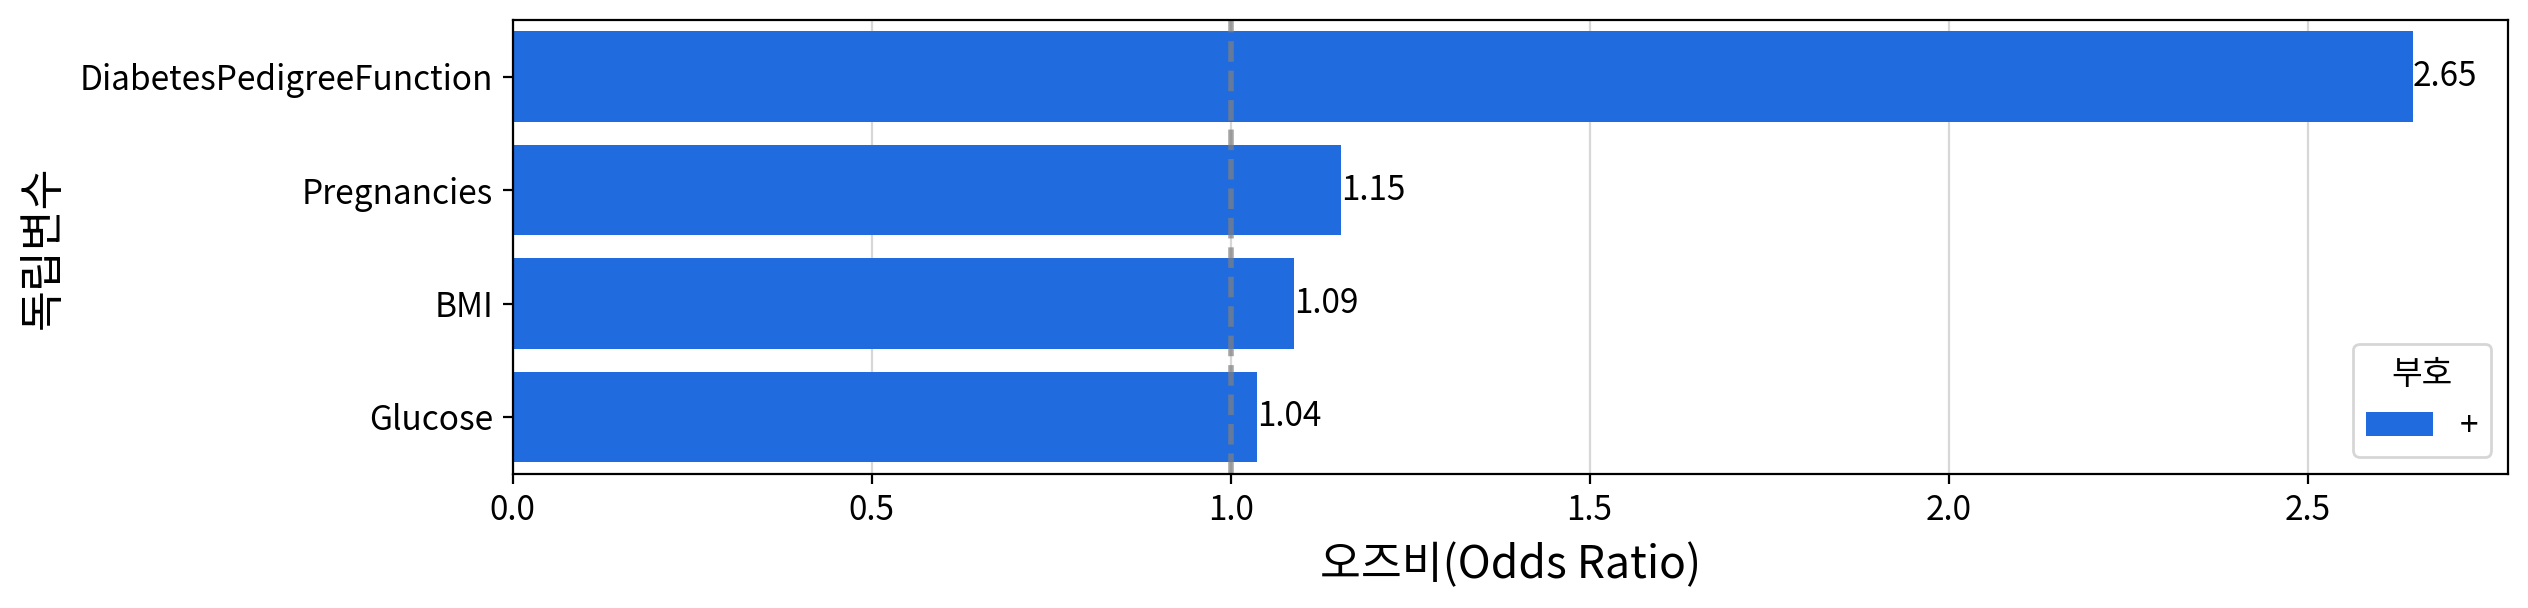

In [16]:
my_logit.auto_logit(df5, y='Outcome', backward=True)